In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import math

Source: https://www.kaggle.com/datasets/ealaxi/paysim1/data

In [2]:
df = pd.read_csv('Synthetic_Financial_Datasets.csv')

In [3]:
df.isFraud.value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [4]:
df.isnull().sum().max()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
df.describe(include='all').round(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1530544995,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433973e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290000e-03,0.000000e+00
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590000e-02,1.590000e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


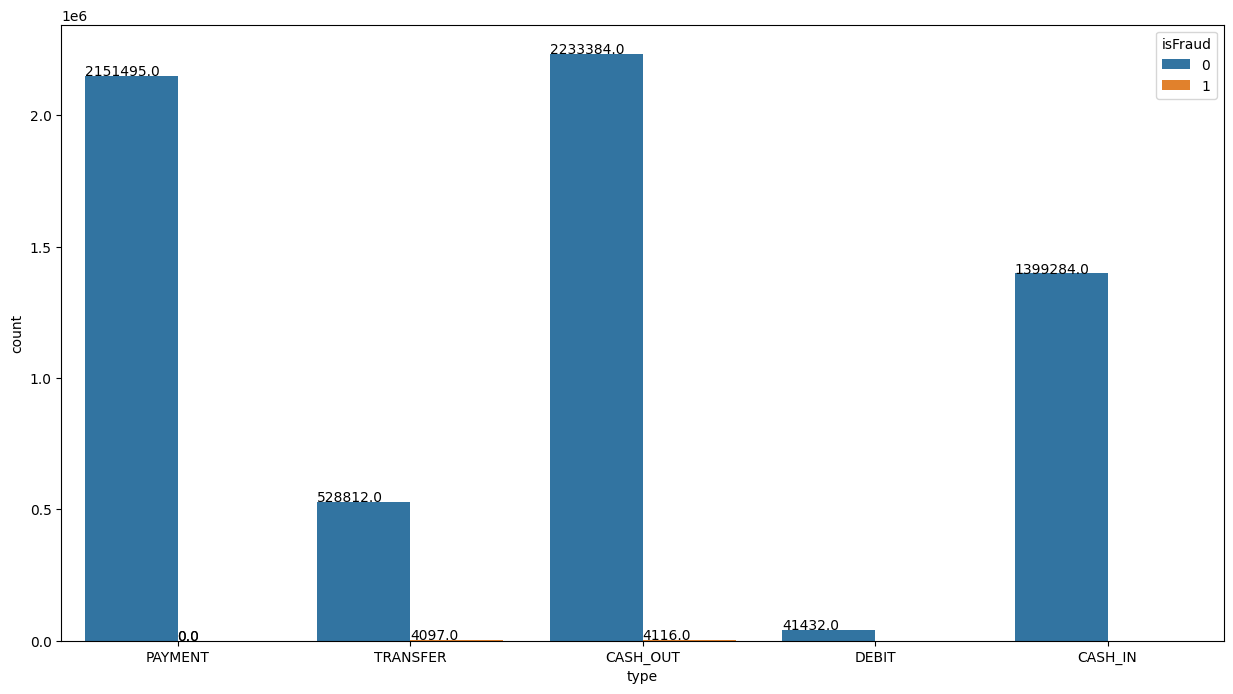

In [9]:
plt.figure(figsize = (15, 8))
ax=sns.countplot(df, x = "type", hue="isFraud")
for p in ax.patches:
        ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x(), p.get_height()))

In [10]:
new_df = pd.DataFrame(df.loc[(df.type == 'TRANSFER') | (df.type == 'CASH_OUT')])
new_df = new_df.drop(['isFlaggedFraud', 'nameOrig', 'nameDest'], axis=1)

In [11]:
new_df.isFraud.value_counts()

isFraud
0    2762196
1       8213
Name: count, dtype: int64

In [12]:
new_df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
2,1,TRANSFER,181.00,181.0,0.0,0.0,0.00,1
3,1,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1
15,1,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0
19,1,TRANSFER,215310.30,705.0,0.0,22425.0,0.00,0
24,1,TRANSFER,311685.89,10835.0,0.0,6267.0,2719172.89,0


One-hot encoding (Error if there are nameOrig, nameDest) (MemoryError: Unable to allocate)

In [36]:
s = (new_df.dtypes == 'object')
object_cols = list(s[s].index)
object_cols

['type']

In [37]:
# Encode
new_df_enc = pd.DataFrame(pd.get_dummies(new_df[object_cols], prefix=object_cols, dtype = int))
new_df_num = new_df.drop(object_cols, axis=1)
new_df_prossed = pd.concat([new_df_enc, new_df_num], axis=1)

In [38]:
# X = new_df_prossed.drop(['isFraud'], axis=1)
# y = new_df_prossed['isFraud']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
# X_sc_train = RobustScaler().set_output(transform='pandas').fit_transform(X_train)
# X_sc_test = RobustScaler().set_output(transform='pandas').fit_transform(X_test)

In [40]:
df_train, df_test= train_test_split(new_df_prossed, train_size=0.8, random_state=42, stratify=new_df_prossed.isFraud)

In [41]:
#Scaling
rs = RobustScaler()
df_sc_train= rs.set_output(transform='pandas').fit_transform(df_train)
df_sc_test= rs.set_output(transform='pandas').transform(df_test)

In [42]:
X_sc_train = df_sc_train.drop('isFraud', axis=1)
y_train = df_sc_train['isFraud']
X_sc_test = df_sc_test.drop('isFraud', axis=1)
y_test = df_sc_test['isFraud']

ROC_curve, Precision-Recall Curve function

In [43]:
def plot_roc(fpr, tpr):
    plt.plot(fpr, tpr, label='ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend()
    plt.show()

In [44]:
def plot_prc(precision, recall):
    plt.plot(precision, recall, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

ML

Baseline (RobustScaler)

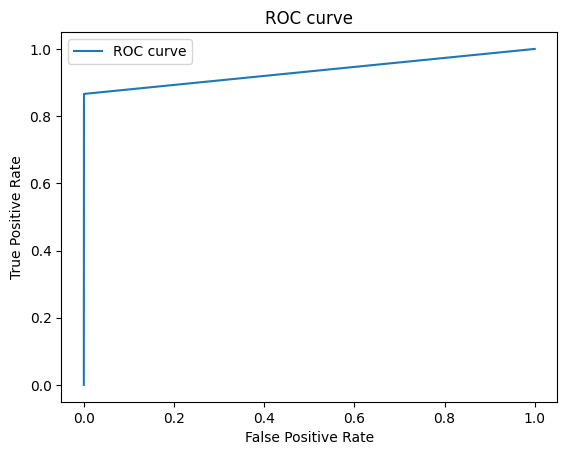

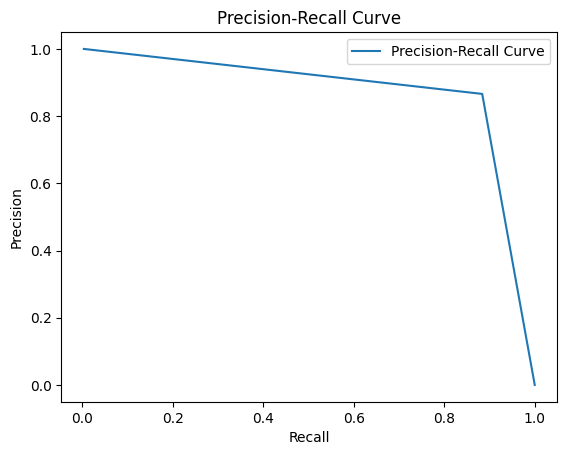

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.88      0.87      0.87      1643

    accuracy                           1.00    554082
   macro avg       0.94      0.93      0.94    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9328800506052684
AUC: 0.8751732924712529
Log_loss: 0.0264758048977783


In [46]:
dt = DecisionTreeClassifier()
dt_model = dt.fit(X_sc_train, y_train)
fpr, tpr, _ = roc_curve(y_test, dt_model.predict_proba(X_sc_test)[:, 1])
precision, recall, thresholds = precision_recall_curve(y_test, dt_model.predict_proba(X_sc_test)[:, 1])
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, dt_model.predict(X_sc_test), target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, dt_model.predict_proba(X_sc_test)[:, 1]))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,dt_model.predict_proba(X_sc_test)))

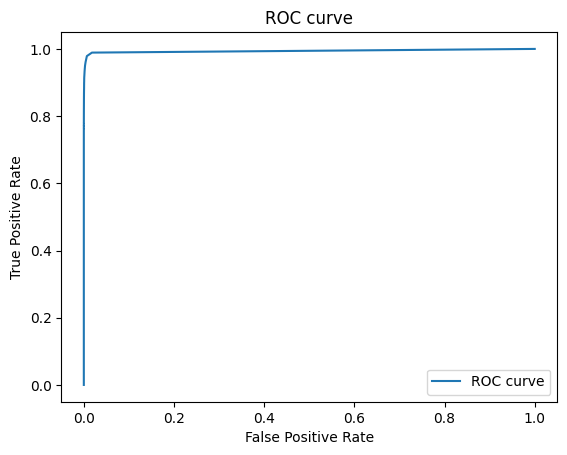

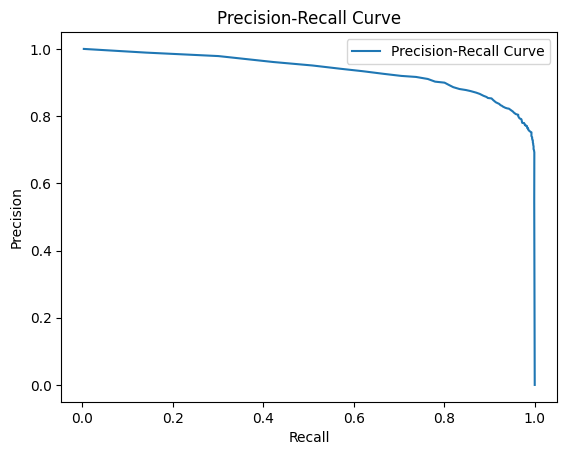

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.98      0.78      0.86      1643

    accuracy                           1.00    554082
   macro avg       0.99      0.89      0.93    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9940569522916963
AUC: 0.9356755201304849
Log_loss: 0.003237247042584942


In [47]:
rf = RandomForestClassifier()
rf_model = rf.fit(X_sc_train, y_train)
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_sc_test)[:, 1])
precision, recall, thresholds = precision_recall_curve(y_test, rf_model.predict_proba(X_sc_test)[:, 1])
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, rf_model.predict(X_sc_test), target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_sc_test)[:, 1]))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,rf_model.predict_proba(X_sc_test)))

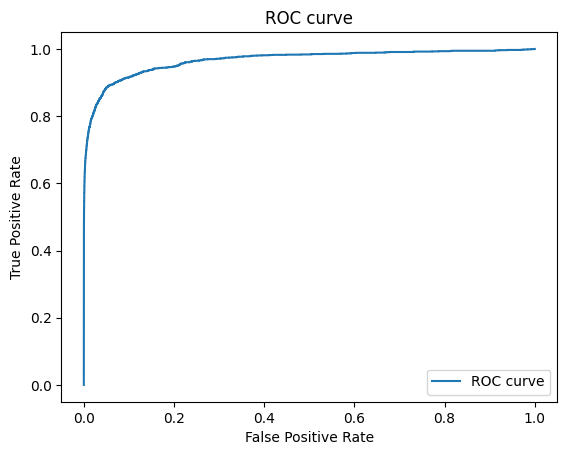

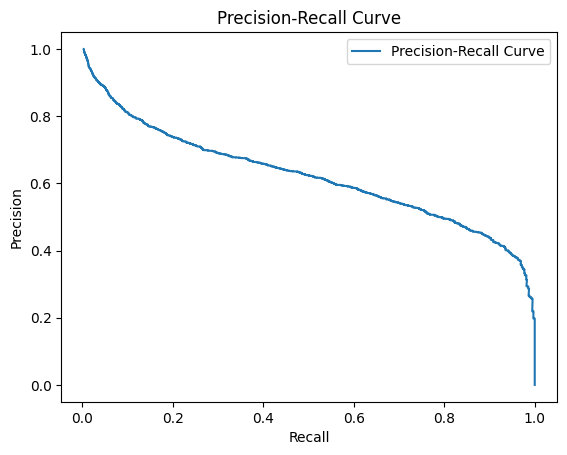

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.88      0.45      0.60      1643

    accuracy                           1.00    554082
   macro avg       0.94      0.73      0.80    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9667203968222029
AUC: 0.6209875994076944
Log_loss: 0.00844130731908064


In [48]:
lg = LogisticRegression(max_iter=600, penalty="l2", warm_start=False)
lg_model = lg.fit(X_sc_train, y_train)
fpr, tpr, _ = roc_curve(y_test, lg_model.predict_proba(X_sc_test)[:, 1])
precision, recall, thresholds = precision_recall_curve(y_test, lg_model.predict_proba(X_sc_test)[:, 1])
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, lg_model.predict(X_sc_test), target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, lg_model.predict_proba(X_sc_test)[:, 1]))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,lg_model.predict_proba(X_sc_test)))

Deep learning

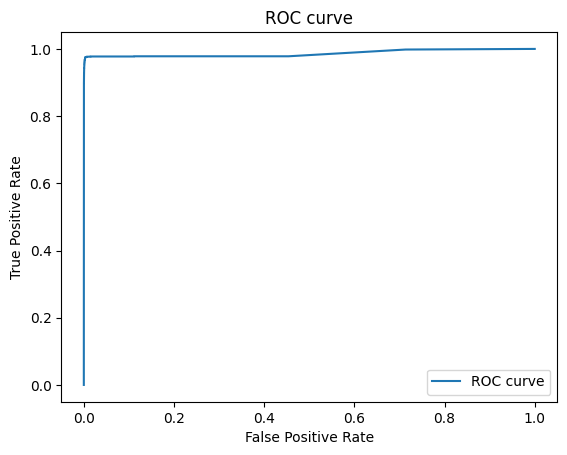

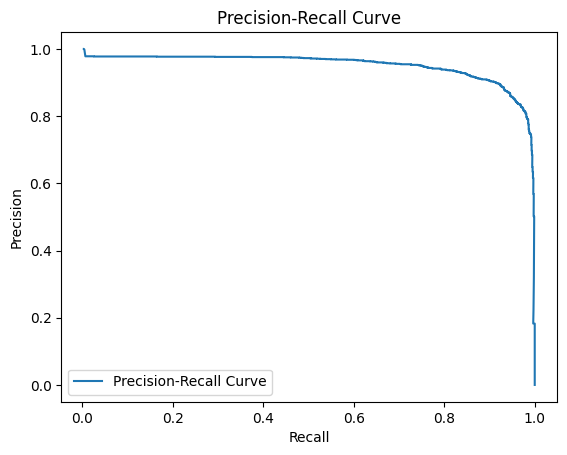

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.96      0.84      0.90      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.92      0.95    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9865598102839868
AUC: 0.9515839711745478
Log_loss: 0.0021810136157439466


In [57]:
# PyTorch RNN Model
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(Net, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, h_n = self.rnn(x, h0)
        out = out[:, -1, :]  # Take last output
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=1)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # if (epoch + 1) % 50 == 0:
        #     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=1)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()


# Hyperparameters
input_size = 8
hidden_size = 2
num_layers = 3
num_classes = 2
local_epochs = 2000
device = torch.device('cpu')

# Initialize model
rnn_model = Net(input_size, hidden_size, num_layers, num_classes)
# print(f"RNN Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(rnn_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(rnn_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))


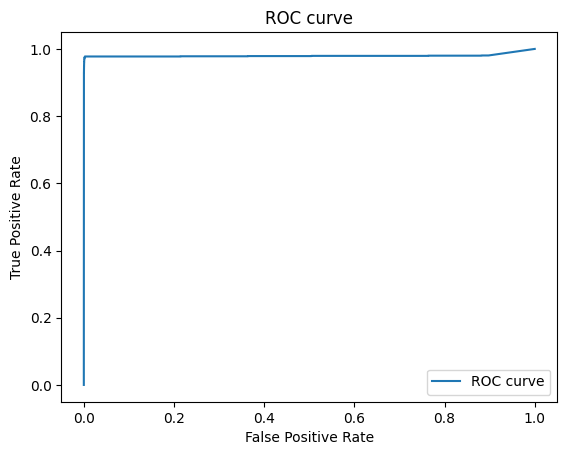

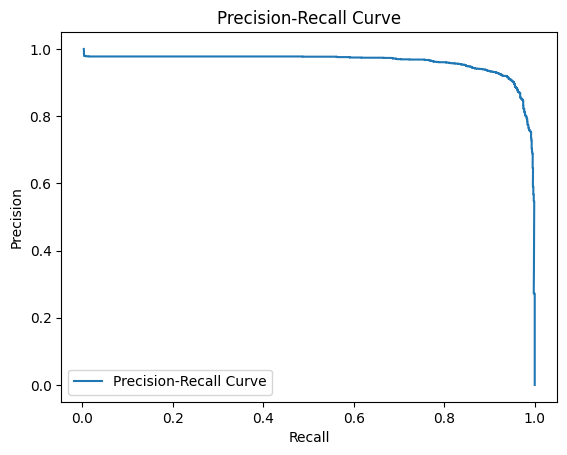

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.96      0.88      0.92      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.94      0.96    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9798075419385417
AUC: 0.9612837415687668
Log_loss: 0.0018270972915004255


In [58]:
# PyTorch GRU Model
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(Net, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, h_n = self.gru(x, h0)
        out = out[:, -1, :]  # Take last output
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=1)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # if (epoch + 1) % 50 == 0:
        #     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=1)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()


# Hyperparameters
input_size = 8
hidden_size = 2
num_layers = 3
num_classes = 2
local_epochs = 2000
device = torch.device('cpu')

# Initialize model
gru_model = Net(input_size, hidden_size, num_layers, num_classes)
# print(f"GRU Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(gru_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(gru_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))

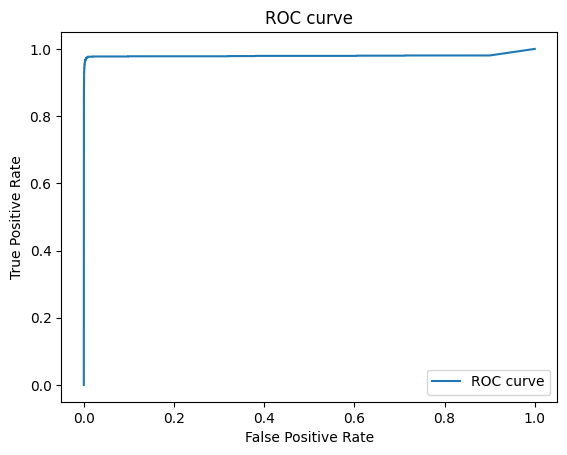

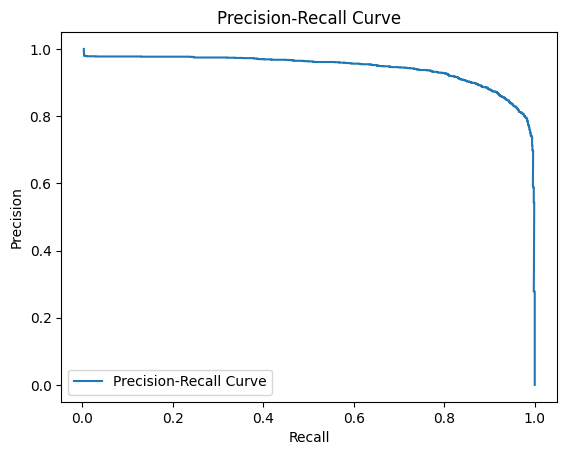

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.96      0.82      0.89      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.91      0.94    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9800432360770903
AUC: 0.9439449303448406
Log_loss: 0.0026850990235057952


In [51]:
# PyTorch LSTM Model
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(Net, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x,(h0,c0))   # out = batch_size, seq_legnth, hidden_size
        out = out [:, -1, :]
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=1)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # if (epoch + 1) % 50 == 0:
        #     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=1)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()


# Hyperparameters
input_size = 8
hidden_size = 2
num_layers = 3
num_classes = 2
local_epochs = 1800
device = torch.device('cpu')

# Initialize model
lstm_model = Net(input_size, hidden_size, num_layers, num_classes)
# print(f"LSTM Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(lstm_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(lstm_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))

Epoch [50/700], Loss: 0.0163
Epoch [100/700], Loss: 0.0148
Epoch [150/700], Loss: 0.0132
Epoch [200/700], Loss: 0.0116
Epoch [250/700], Loss: 0.0104
Epoch [300/700], Loss: 0.0096
Epoch [350/700], Loss: 0.0090
Epoch [400/700], Loss: 0.0084
Epoch [450/700], Loss: 0.0076
Epoch [500/700], Loss: 0.0072
Epoch [550/700], Loss: 0.0070
Epoch [600/700], Loss: 0.0070
Epoch [650/700], Loss: 0.0085
Epoch [700/700], Loss: 0.0073


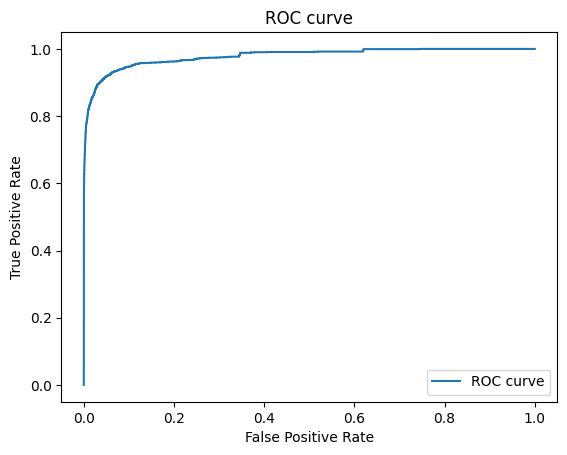

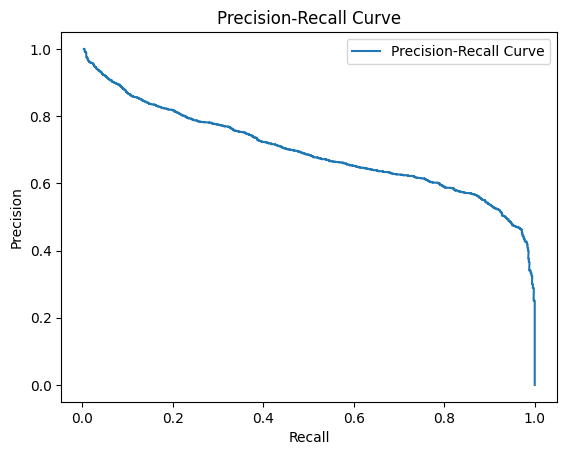

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.94      0.49      0.65      1643

    accuracy                           1.00    554082
   macro avg       0.97      0.75      0.82    554082
weighted avg       1.00      1.00      1.00    554082

ROC_AUC: 0.9785924109326565
AUC: 0.6962360752153208
Log_loss: 0.006948528936513456


In [59]:
# PyTorch Muti-head attention Model
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

class MultiheadAttention(nn.Module):

    def __init__(self, input_dim, dim_model, num_heads):
        super().__init__()
        self.input_dim = input_dim
        self.dim_model = dim_model
        self.num_heads = num_heads
        self.head_dim = dim_model // num_heads
        
        self.qkv_layer = nn.Linear(input_dim , 3 * dim_model)
        self.linear_layer = nn.Linear(dim_model, dim_model)
    
    def forward(self, x, mask):
        batch_size, sequence_length, input_dim = x.size()
        qkv = self.qkv_layer(x)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        qkv = qkv.permute(0, 2, 1, 3)   # change position to [batch_size, num_heads, sequence_length, 3*head_dim]
        q, k, v = qkv.chunk(3, dim=-1)
        values, attention = scaled_dot_product(q, k, v, mask)
        values = values.reshape(batch_size, sequence_length, self.num_heads * self.head_dim)
        out = self.linear_layer(values)
        return out, values

class Net(nn.Module):
    def __init__(self, input_dim, dim_model, num_classes, num_heads):
        super(Net, self).__init__()
        self.multihead_attention = MultiheadAttention(input_dim=input_dim, dim_model=dim_model, num_heads=num_heads)
        self.layer_norm = nn.LayerNorm(dim_model)
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(dim_model, num_classes)
    
    def forward(self, x, mask=None):
        # Apply Multihead Attention
        attn_output, _ = self.multihead_attention(x, mask)
        
        # Add normalization and dropout for better training
        attn_output = self.layer_norm(attn_output)
        attn_output = self.dropout(attn_output)
        
        # Use global average pooling instead of just last position, this considers all feature relationships learned by attention
        out = torch.mean(attn_output, dim=1)  # [batch_size, dim_model]
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=2)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=2)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()

# Hyperparameters
input_dim = 1
dim_model = 32
num_classes = 2
num_heads = 4
local_epochs = 700
device = torch.device('cpu')

# Initialize model
muti_head_model = Net(input_dim, dim_model, num_classes, num_heads)
# print(f"LSTM Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(muti_head_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(muti_head_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))


Export dataset

In [ ]:
df_2 = pd.concat([df_train, df_test], axis=0, join='inner')
df_2.to_csv('df_2.csv')
df_2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,Amount,Class
0,0.905774,0.862468,-0.582668,-0.800214,-0.402839,1.195050,3.686711,-1.352372,2.084633,1.176746,-0.064710,-0.054899,0.360069,0.057693,-0.126514,-0.204315,0.0
1,0.465984,0.902013,-0.081009,-1.688308,0.169440,2.300397,3.063923,-0.037911,1.216367,0.077896,0.381968,-0.149059,0.179281,-0.298349,0.731565,-0.264579,0.0
2,-0.512286,-0.452072,0.383882,0.277401,-0.610965,-0.591610,1.912709,-2.004449,-9.447616,0.041519,-1.935343,-0.237061,1.642080,0.581564,0.079721,2.130828,0.0
3,0.561678,1.014098,-1.115745,-0.483481,-1.036093,-1.027641,-0.065331,-1.306396,-0.024659,-0.862125,1.867901,0.083076,-0.846429,-0.346752,-0.266762,-0.221294,0.0
4,-0.298886,-0.209097,-0.767259,-0.033341,-2.160256,0.591186,0.108623,0.412743,-0.255824,0.004740,-0.470268,-0.146506,-0.192895,-0.586314,0.092699,0.892136,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56957,-0.451936,-0.394428,0.114558,1.188076,0.399184,0.093532,1.706819,-0.262368,1.498209,0.369894,-0.764704,0.049701,-0.247677,-1.177335,-0.078327,0.194433,0.0
56958,0.487514,0.616910,-1.062926,-0.286197,0.574551,-0.851182,0.092186,-0.321318,-0.086414,1.494857,-0.364658,-0.895844,0.524050,-0.042493,-0.501380,3.836186,0.0
56959,0.954532,-0.477036,0.442307,0.008131,-2.241134,0.105634,-0.145702,0.196489,0.810556,1.030083,-1.657091,-0.114667,1.030255,0.257837,0.127593,-0.078079,0.0
56960,0.927739,0.957849,-0.819157,-0.541479,-0.695126,-0.454421,0.436020,-1.072366,0.214734,0.004344,1.013781,0.175753,-0.344969,-0.029767,-0.356655,-0.028532,0.0


Export dataset test and train

In [ ]:
df_sc_train.to_csv('df_train_2.csv')
df_sc_test.to_csv('df_test_2.csv')

In [ ]:
# df_train = pd.read_csv('df_train_2.csv')
# df_test = pd.read_csv('df_test_2.csv')
# df_train.drop("Unnamed: 0", axis=1, inplace=True)
# df_test.drop("Unnamed: 0", axis=1, inplace=True)

In [71]:
# X_train = df_train.drop('isFraud', axis=1)
# y_train = df_train['isFraud']
# X_test = df_test.drop('isFraud', axis=1)
# y_test = df_test['isFraud']

In [72]:
# df_new = df_train.sample(frac = 0.25)
# # df_new.drop("Unnamed: 0", axis=1, inplace=True)
# X = df_new.drop('isFraud', axis=1).values
# y = df_new['isFraud'].values
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ,stratify=y)

In [73]:
# lg = LogisticRegression(max_iter=600, penalty="l2", warm_start=False)
# lg_model = lg.fit(X_train, y_train)
# fpr, tpr, _ = roc_curve(y_test, lg_model.predict_proba(X_test)[:, 1])
# precision, recall, thresholds = precision_recall_curve(y_test, lg_model.predict_proba(X_test)[:, 1])
# print(classification_report(y_test, lg_model.predict(X_test), target_names=['Not Fraud', 'Fraud']))
# print("ROC_AUC:", roc_auc_score(y_test, lg_model.predict_proba(X_test)[:, 1]))
# print("AUC:", auc(recall, precision))
# print("Log_loss:", log_loss(y_test,lg_model.predict_proba(X_test)))